<a href="https://colab.research.google.com/github/Prajkta11222/Smart-Vehical-Health-Intelligence-and-Predictive-Maintenance-Recommendation-System/blob/main/Vehical_maintence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---
#Smart-Vehical-Health-Intelligence-and-Predictive-Maintenance-Recommendation-System


---



In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:

# =============================================================================
# Dataset Path
# =============================================================================

DATASET_PATH = "/content/drive/MyDrive/Btech Final Year Project/Dataset/flex_fuel_predictive_maintenance_dataset_augmented.csv"

# =============================================================================
# Load Dataset
# =============================================================================

from pathlib import Path
import pandas as pd

# Check whether the dataset exists
if not Path(DATASET_PATH).exists():
    raise FileNotFoundError(
        f"Dataset not found.\nPlease check the path:\n{DATASET_PATH}"
    )

# Load dataset
vehicle_df = pd.read_csv(DATASET_PATH)

# Check if dataset is empty
if vehicle_df.empty:
    raise ValueError("The dataset is empty.")

print("✅ Dataset loaded successfully.")
print(f"Shape : {vehicle_df.shape}")

# Display first 5 rows
display(vehicle_df.head())

✅ Dataset loaded successfully.
Shape : (120000, 56)


,Vehicle_ID,Timestamp,Vehicle_Model,Vehicle_Age_years,Engine_Size_cc,Fuel_System_Material_Compatibility,Climate_Region,Ambient_Temperature_C,Humidity_Pct,Altitude_m,...,Fuel_Line_Seal_Condition,O2_Sensor_Response_ms,Cold_Start_Duration_s,Cranking_Voltage_V,Time_Since_Last_Service_days,Time_Since_Injector_Replacement_km,Time_Since_SparkPlug_Replacement_km,Need_Maintenance,Failure_Type,Remaining_Useful_Life_km
0,FFV2-000001,2023-07-04,Truck,10,2876,Standard,Coastal,22.3,73.3,394.0,...,Pass,151.0,1.47,11.70,19.0,140675.0,19822.0,Yes,Catalytic Converter,5383.0
1,FFV2-000002,2024-08-21,SUV,8,1935,Retrofit-Upgraded,Arid,22.7,29.3,629.0,...,Pass,140.0,1.74,11.79,93.0,158999.0,13537.0,Yes,Electrical,4120.0
2,FFV2-000003,2024-02-28,Truck,3,2964,Ethanol-Compatible (Tier-2/3),Arid,35.5,21.6,1538.0,...,Pass,96.0,1.47,12.10,221.0,51807.0,22730.0,No,No Failure,15566.0
3,FFV2-000004,2024-02-09,SUV,10,1945,Standard,Humid,23.8,78.2,391.0,...,Pass,129.0,1.67,NaN,23.0,121717.0,50980.0,Yes,Fuel System,3256.0
4,FFV2-000005,2024-05-16,Car,10,1125,Standard,Arid,40.5,28.0,NaN,...,Pass,160.0,1.86,11.80,195.0,3064.0,84.0,Yes,Injector,1037.0


In [15]:
# =============================================================================
# Stage 1 – Dataset Inspection
# Member 1
# =============================================================================

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 1 – Dataset Inspection")
print("=" * 80)

import pandas as pd
import numpy as np

# =============================================================================
# 1. Dataset Shape
# =============================================================================

print("\n" + "=" * 80)
print("1. DATASET SHAPE")
print("=" * 80)

print(f"Rows    : {vehicle_df.shape[0]:,}")
print(f"Columns : {vehicle_df.shape[1]}")

# =============================================================================
# 2. First Five Records
# =============================================================================

print("\n" + "=" * 80)
print("2. FIRST FIVE RECORDS")
print("=" * 80)

display(vehicle_df.head())

# =============================================================================
# 3. Dataset Information
# =============================================================================

print("\n" + "=" * 80)
print("3. DATASET INFORMATION")
print("=" * 80)

vehicle_df.info()

# =============================================================================
# 4. Data Types
# =============================================================================

print("\n" + "=" * 80)
print("4. DATA TYPES")
print("=" * 80)

display(vehicle_df.dtypes.to_frame(name="Data Type"))

# =============================================================================
# 5. Missing Value Analysis
# =============================================================================

print("\n" + "=" * 80)
print("5. MISSING VALUE ANALYSIS")
print("=" * 80)

missing = pd.DataFrame({
    "Missing Values": vehicle_df.isnull().sum(),
    "Missing Percentage (%)":
    (vehicle_df.isnull().mean()*100).round(2)
})

missing = missing[missing["Missing Values"] > 0]

if missing.empty:
    print("No missing values found.")
else:
    display(
        missing.sort_values(
            by="Missing Percentage (%)",
            ascending=False
        )
    )

# =============================================================================
# 6. Duplicate Analysis
# =============================================================================

print("\n" + "=" * 80)
print("6. DUPLICATE ANALYSIS")
print("=" * 80)

duplicates = vehicle_df.duplicated().sum()

print(f"Duplicate Rows : {duplicates:,}")

# =============================================================================
# 7. Statistical Summary
# =============================================================================

print("\n" + "=" * 80)
print("7. NUMERICAL FEATURE SUMMARY")
print("=" * 80)

display(vehicle_df.describe())

# =============================================================================
# 8. Target Variable Analysis
# =============================================================================

print("\n" + "=" * 80)
print("8. TARGET VARIABLE ANALYSIS")
print("=" * 80)

# -------------------------------------------------------------------------
# Primary Target
# -------------------------------------------------------------------------

print("\nNeed_Maintenance Distribution\n")

display(vehicle_df["Need_Maintenance"].value_counts())

print("\nPercentage Distribution\n")

display(
    (
        vehicle_df["Need_Maintenance"]
        .value_counts(normalize=True)*100
    ).round(2)
)

# -------------------------------------------------------------------------
# Secondary Target
# -------------------------------------------------------------------------

print("\nFailure_Type Distribution\n")

display(vehicle_df["Failure_Type"].value_counts())

# -------------------------------------------------------------------------
# Remaining Useful Life
# -------------------------------------------------------------------------

print("\nRemaining_Useful_Life_km Summary\n")

display(vehicle_df["Remaining_Useful_Life_km"].describe())

# =============================================================================
# 9. Dataset Quality Summary
# =============================================================================

print("\n" + "=" * 80)
print("9. DATASET QUALITY SUMMARY")
print("=" * 80)

print(f"Total Features          : {vehicle_df.shape[1]}")
print(f"Total Records           : {vehicle_df.shape[0]:,}")
print(f"Missing Values          : {vehicle_df.isnull().sum().sum():,}")
print(f"Duplicate Rows          : {duplicates:,}")

numeric = vehicle_df.select_dtypes(include=np.number).shape[1]
categorical = vehicle_df.select_dtypes(
    include=["object", "category", "bool"]
).shape[1]

print(f"Numeric Features        : {numeric}")
print(f"Categorical Features    : {categorical}")

# =============================================================================
# 10. Observations
# =============================================================================

print("\n" + "=" * 80)
print("10. OBSERVATIONS")
print("=" * 80)

print("• Dataset loaded successfully.")
print("• Dataset structure verified.")
print("• Data types inspected.")
print("• Missing values identified.")
print("• Duplicate rows checked.")
print("• Target variables verified.")
print("• Dataset remains unchanged.")
print("• Dataset is ready for Stage 2 (Exploratory Data Analysis).")

SMART VEHICLE HEALTH INTELLIGENCE
Stage 1 – Dataset Inspection

1. DATASET SHAPE
Rows    : 120,000
Columns : 56

2. FIRST FIVE RECORDS


,Vehicle_ID,Timestamp,Vehicle_Model,Vehicle_Age_years,Engine_Size_cc,Fuel_System_Material_Compatibility,Climate_Region,Ambient_Temperature_C,Humidity_Pct,Altitude_m,...,Fuel_Line_Seal_Condition,O2_Sensor_Response_ms,Cold_Start_Duration_s,Cranking_Voltage_V,Time_Since_Last_Service_days,Time_Since_Injector_Replacement_km,Time_Since_SparkPlug_Replacement_km,Need_Maintenance,Failure_Type,Remaining_Useful_Life_km
0,FFV2-000001,2023-07-04,Truck,10,2876,Standard,Coastal,22.3,73.3,394.0,...,Pass,151.0,1.47,11.70,19.0,140675.0,19822.0,Yes,Catalytic Converter,5383.0
1,FFV2-000002,2024-08-21,SUV,8,1935,Retrofit-Upgraded,Arid,22.7,29.3,629.0,...,Pass,140.0,1.74,11.79,93.0,158999.0,13537.0,Yes,Electrical,4120.0
2,FFV2-000003,2024-02-28,Truck,3,2964,Ethanol-Compatible (Tier-2/3),Arid,35.5,21.6,1538.0,...,Pass,96.0,1.47,12.10,221.0,51807.0,22730.0,No,No Failure,15566.0
3,FFV2-000004,2024-02-09,SUV,10,1945,Standard,Humid,23.8,78.2,391.0,...,Pass,129.0,1.67,NaN,23.0,121717.0,50980.0,Yes,Fuel System,3256.0
4,FFV2-000005,2024-05-16,Car,10,1125,Standard,Arid,40.5,28.0,NaN,...,Pass,160.0,1.86,11.80,195.0,3064.0,84.0,Yes,Injector,1037.0



3. DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 56 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Vehicle_ID                           120000 non-null  object 
 1   Timestamp                            120000 non-null  object 
 2   Vehicle_Model                        120000 non-null  object 
 3   Vehicle_Age_years                    120000 non-null  int64  
 4   Engine_Size_cc                       120000 non-null  int64  
 5   Fuel_System_Material_Compatibility   120000 non-null  object 
 6   Climate_Region                       120000 non-null  object 
 7   Ambient_Temperature_C                117547 non-null  float64
 8   Humidity_Pct                         115229 non-null  float64
 9   Altitude_m                           112788 non-null  float64
 10  Ethanol_Content_Pct                  120000 non-null  fl

,Data Type
Vehicle_ID,object
Timestamp,object
Vehicle_Model,object
Vehicle_Age_years,int64
Engine_Size_cc,int64
Fuel_System_Material_Compatibility,object
Climate_Region,object
Ambient_Temperature_C,float64
Humidity_Pct,float64
Altitude_m,float64



5. MISSING VALUE ANALYSIS


...


Failure_Type Distribution



,count
Failure_Type,
No Failure,60833
Fuel System,10071
Cooling System,9685
Electrical,8615
Ignition,8501
Injector,8069
Lubrication,7341
Catalytic Converter,6885



Remaining_Useful_Life_km Summary



,Remaining_Useful_Life_km
count,120000.000000
mean,10092.204903
std,4791.888194
min,200.000000
25%,6047.270000
50%,10399.620000
75%,14293.355000
max,20000.000000



9. DATASET QUALITY SUMMARY
Total Features          : 56
Total Records           : 120,000
Missing Values          : 156,626
Duplicate Rows          : 0
Numeric Features        : 45
Categorical Features    : 11

10. OBSERVATIONS
• Dataset loaded successfully.
• Dataset structure verified.
• Data types inspected.
• Missing values identified.
• Duplicate rows checked.
• Target variables verified.
• Dataset remains unchanged.
• Dataset is ready for Stage 2 (Exploratory Data Analysis).


SMART VEHICLE HEALTH INTELLIGENCE
Stage 2 – Exploratory Data Analysis (EDA)

1. Need_Maintenance Distribution


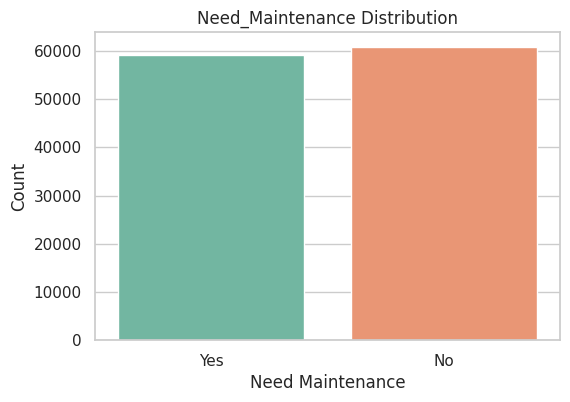

Need_Maintenance
No     50.694167
Yes    49.305833
Name: proportion, dtype: float64

2. Failure Type Distribution


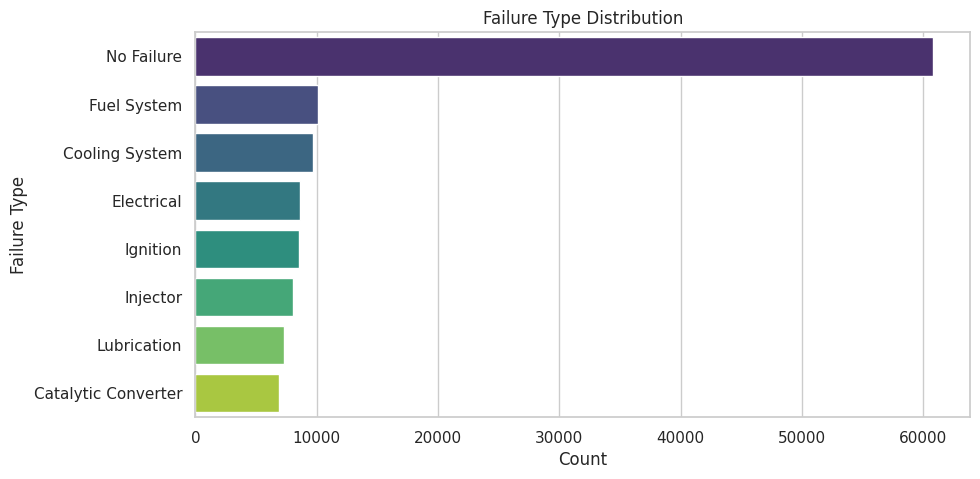


3. Remaining Useful Life Distribution


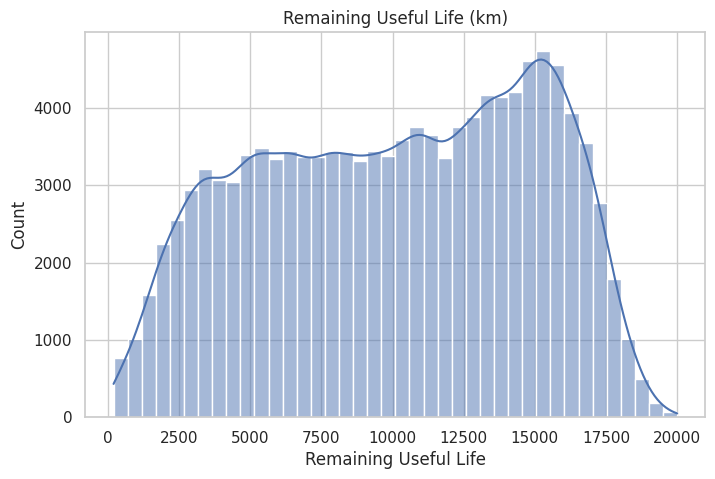


4. Missing Value Analysis


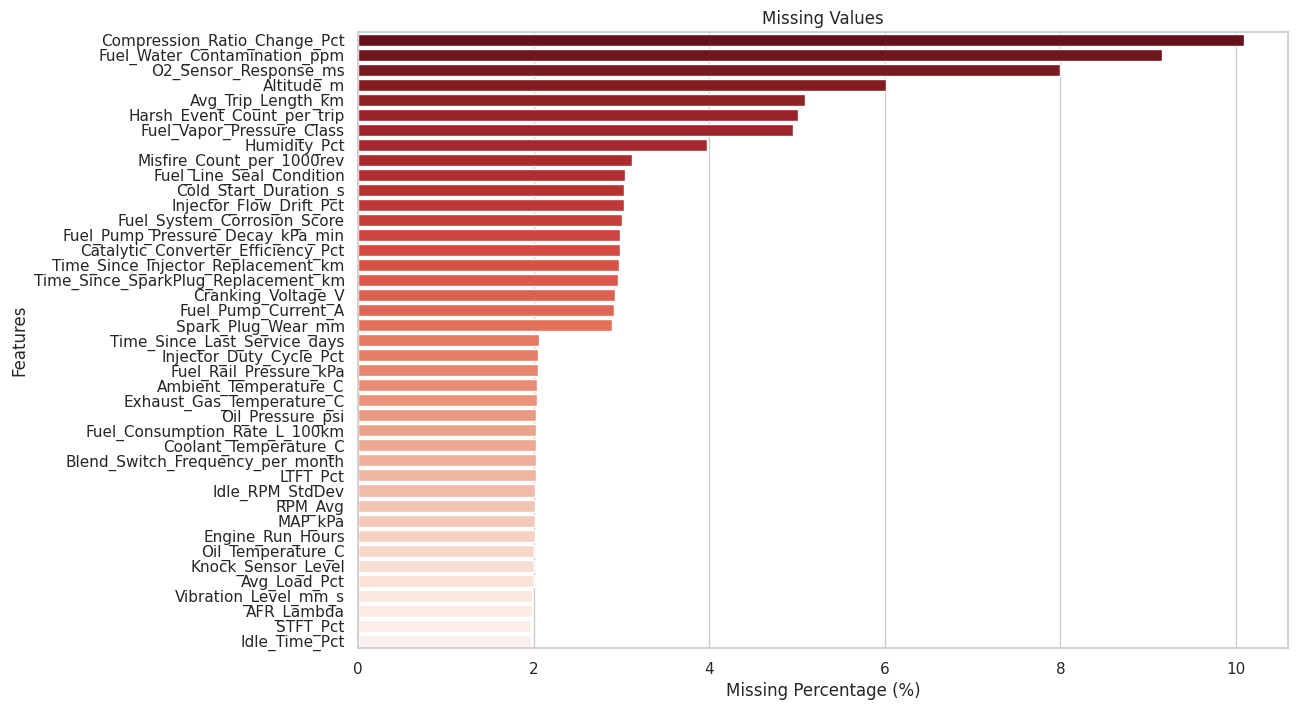


5. Numerical Feature Distribution


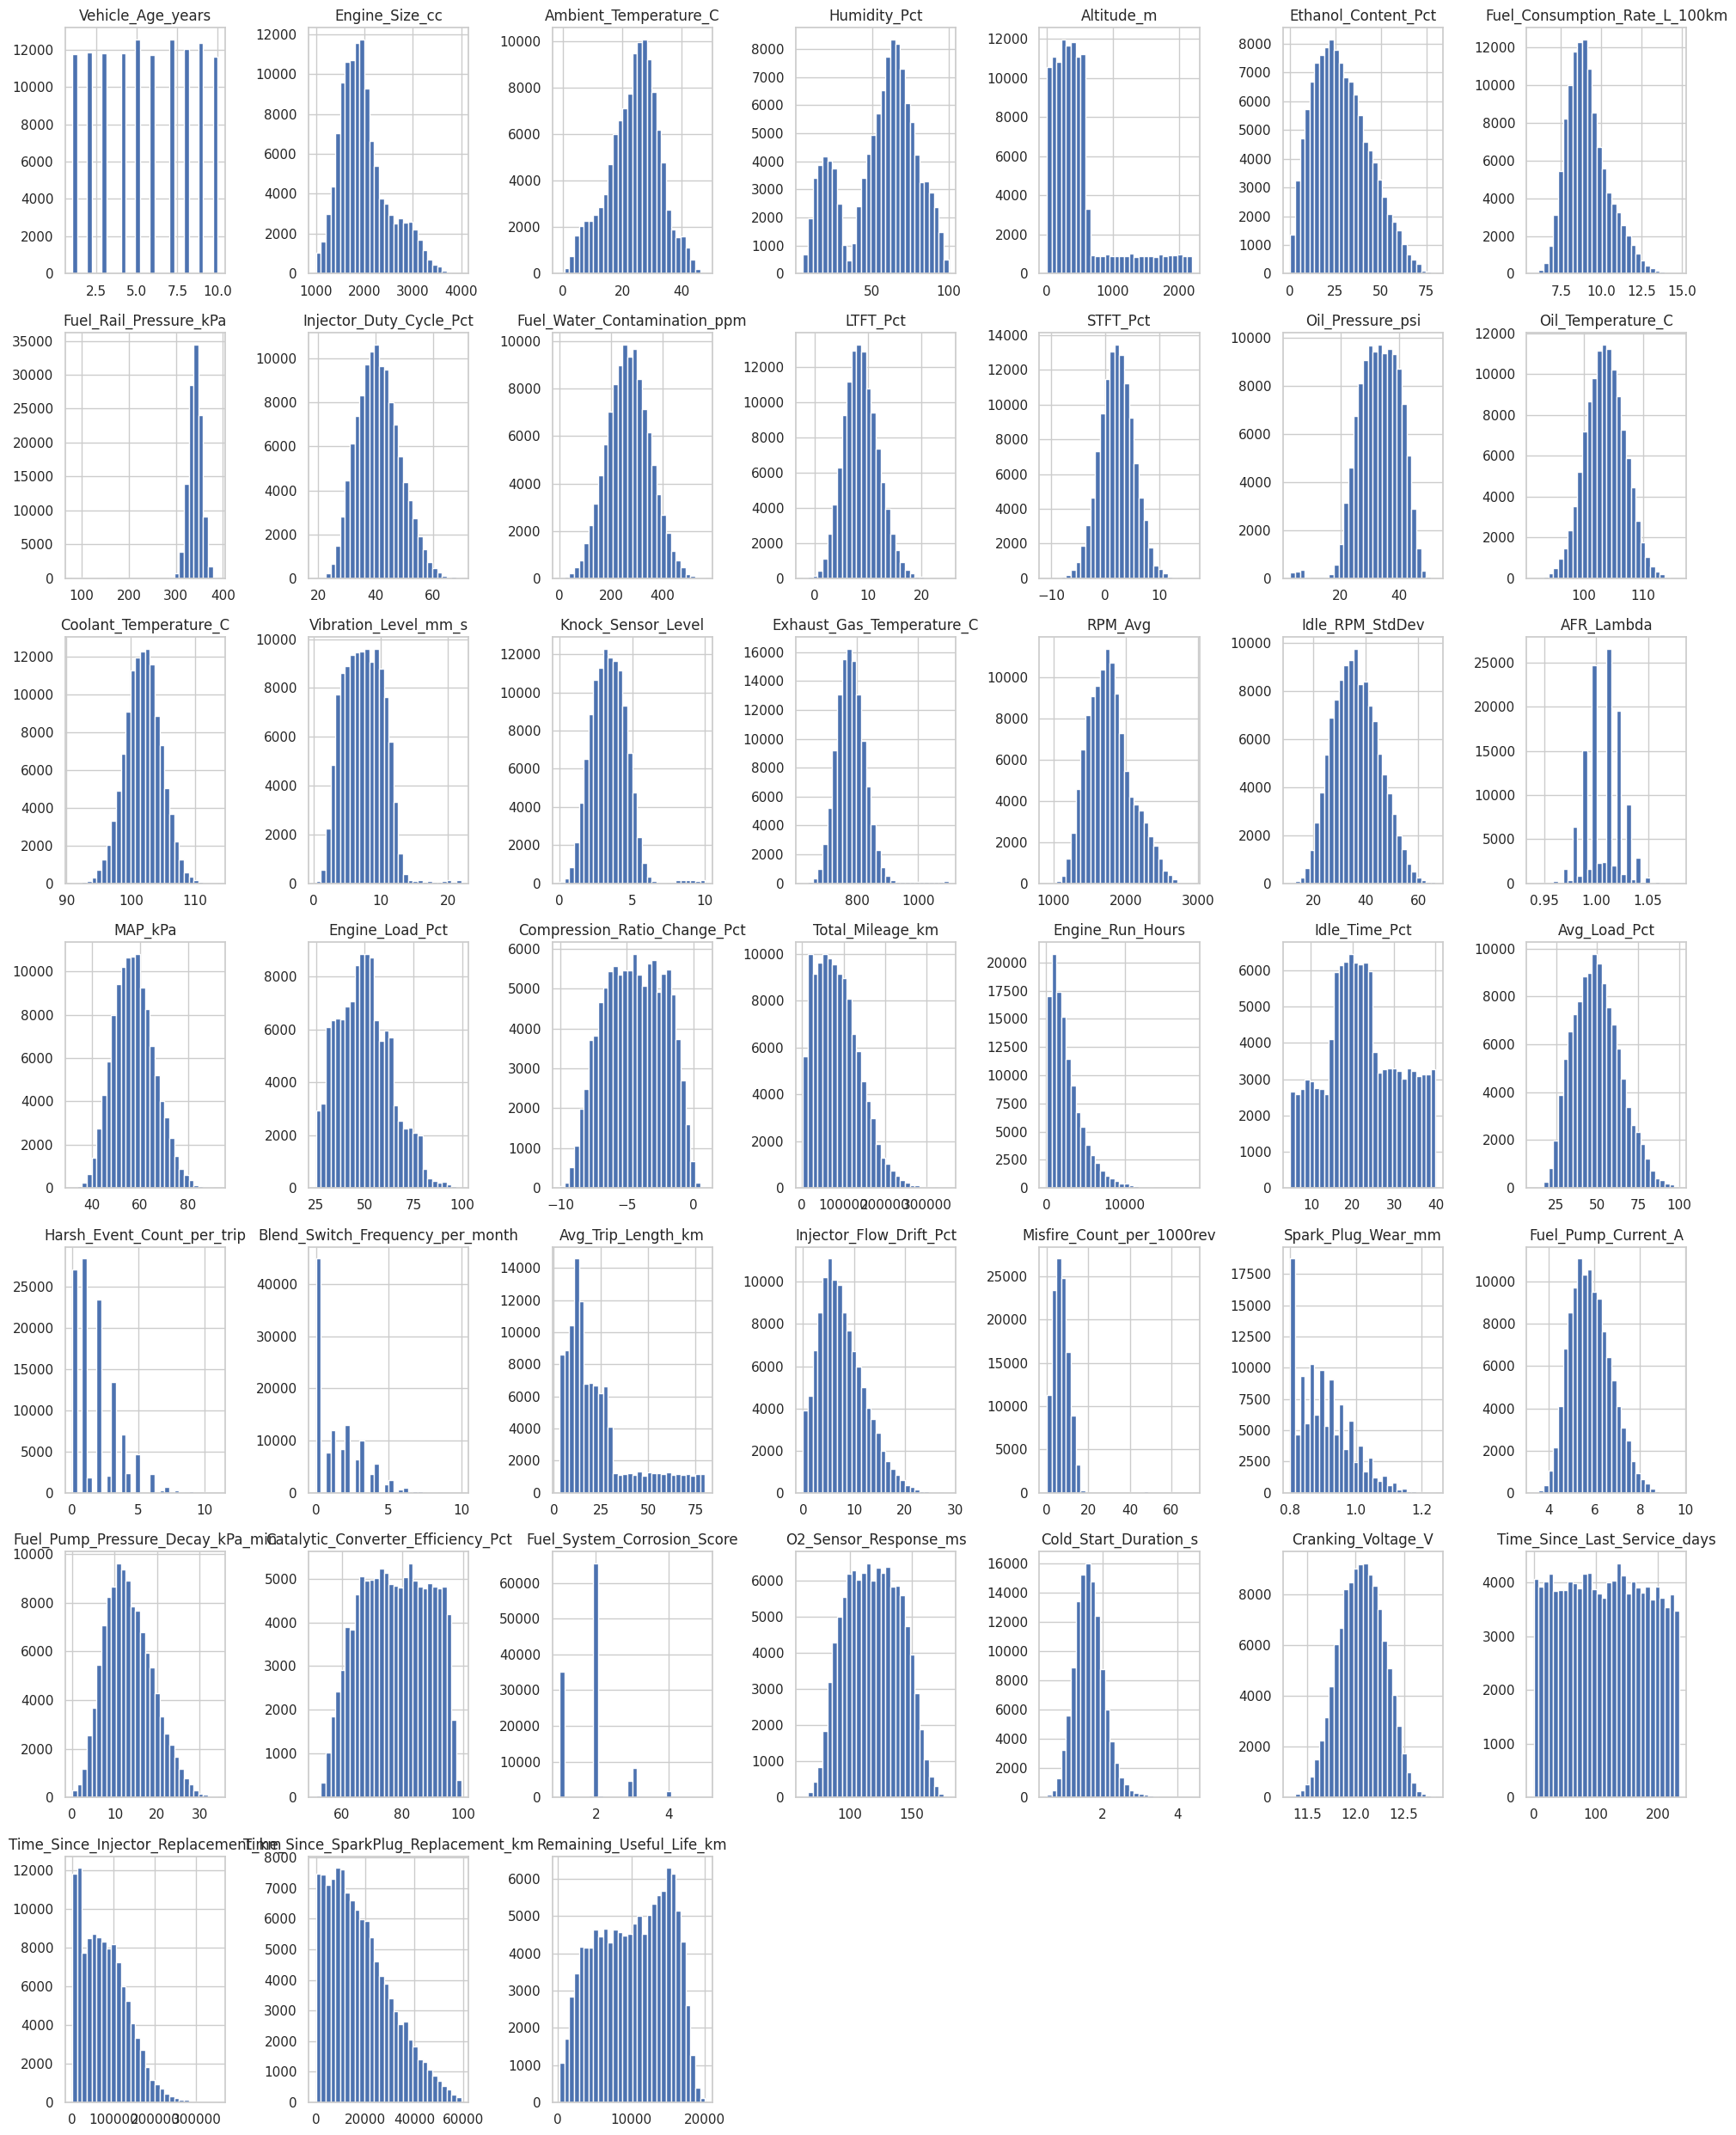


6. Correlation Heatmap


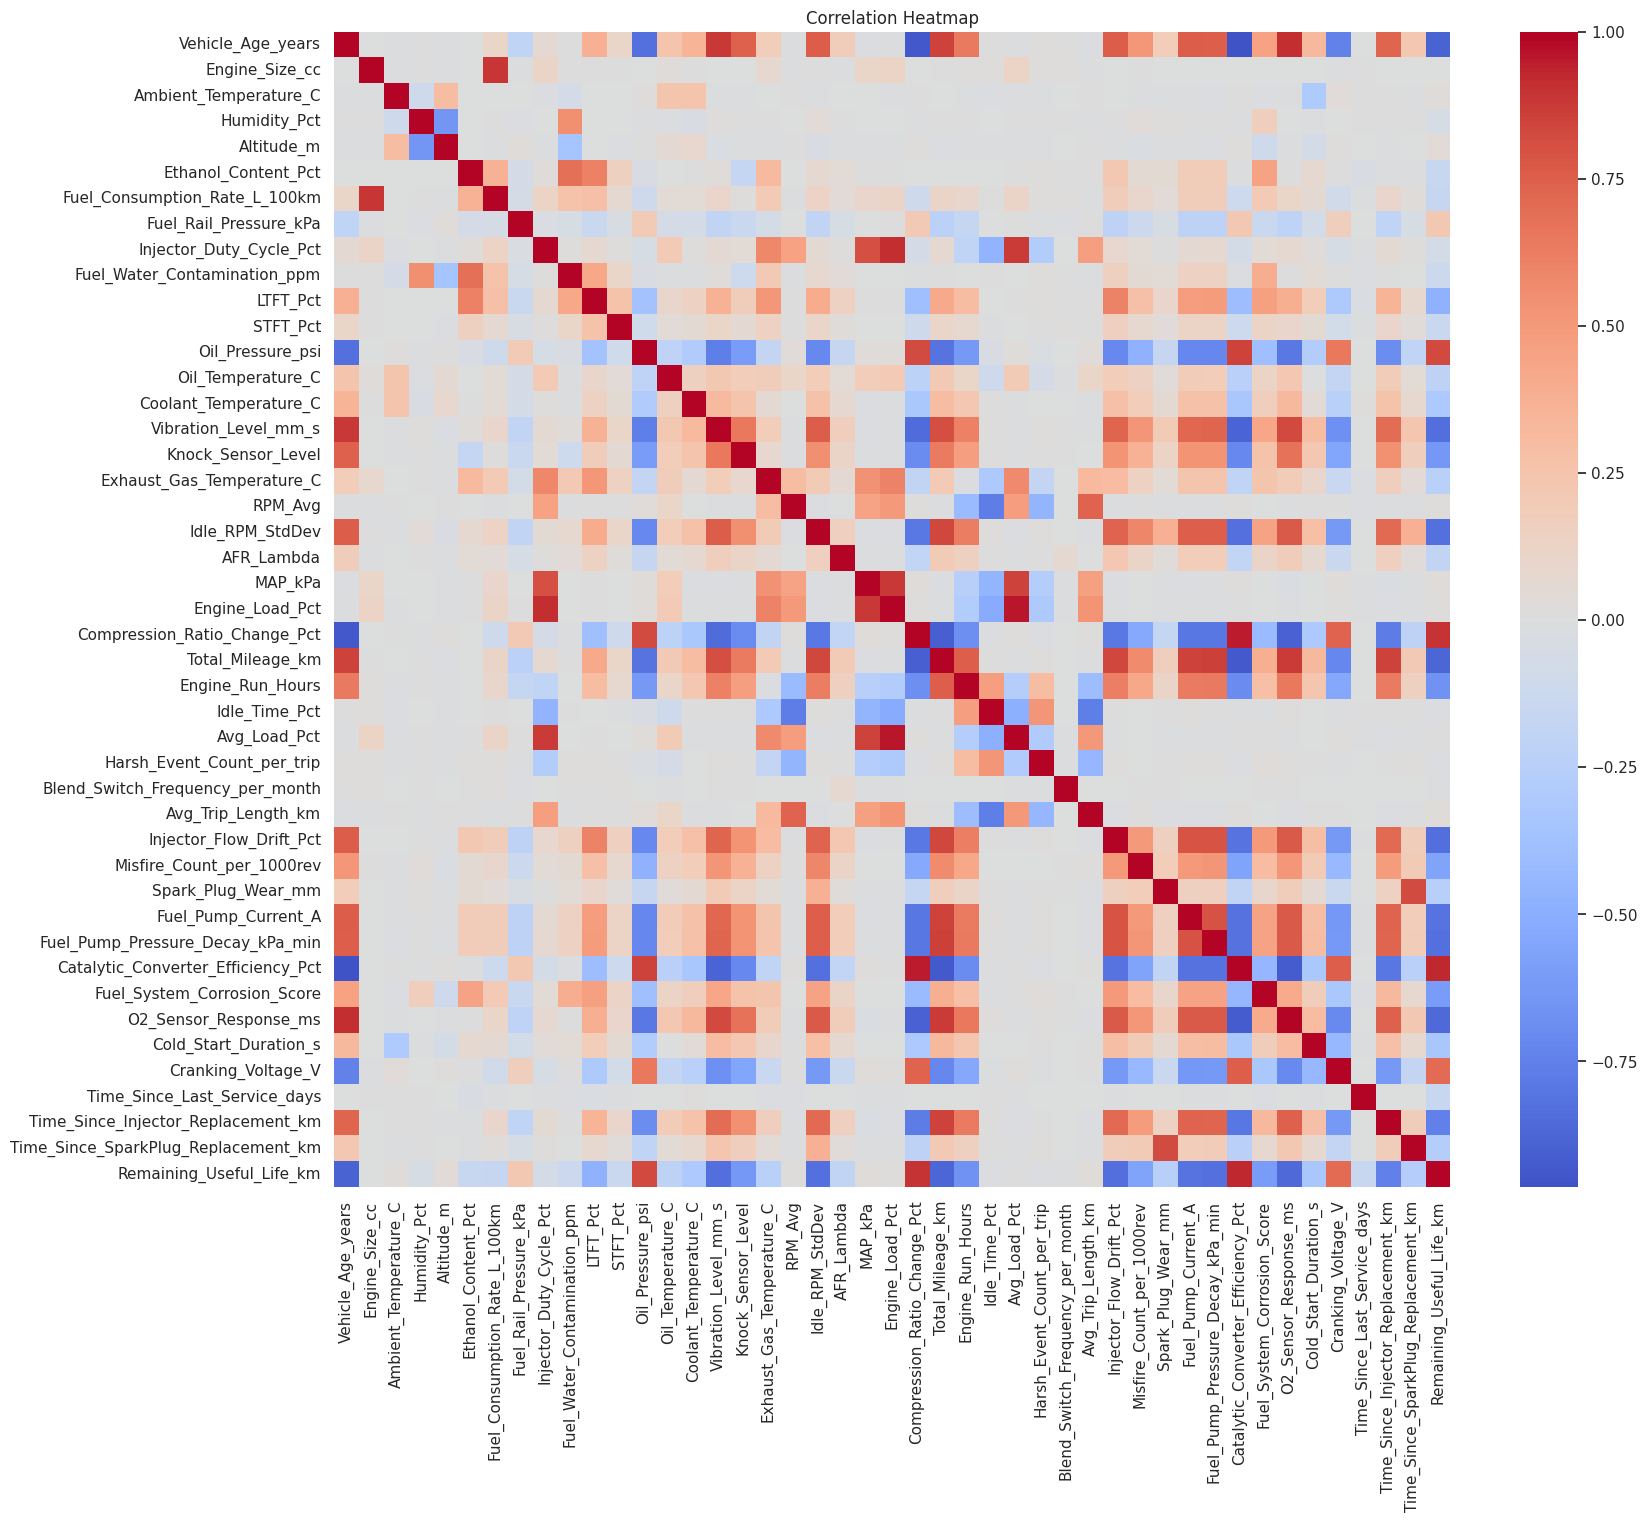


7. Outlier Analysis


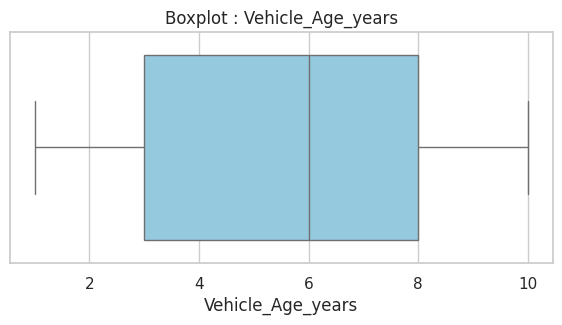

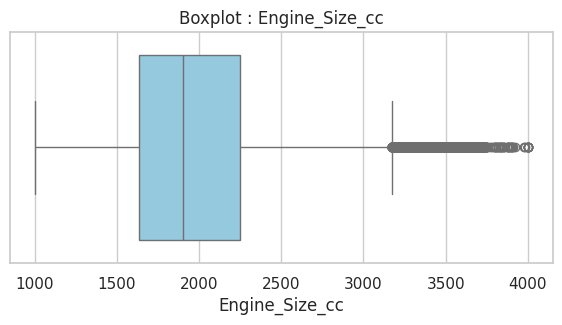

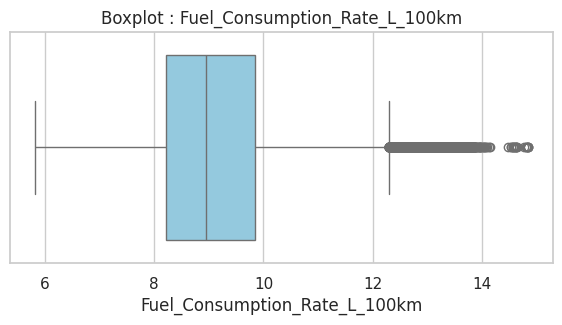

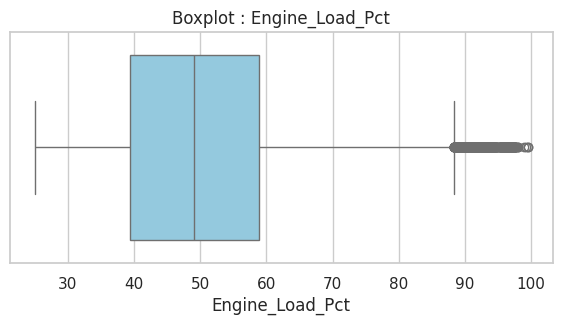

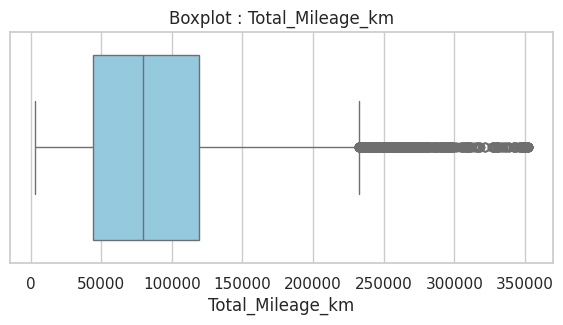

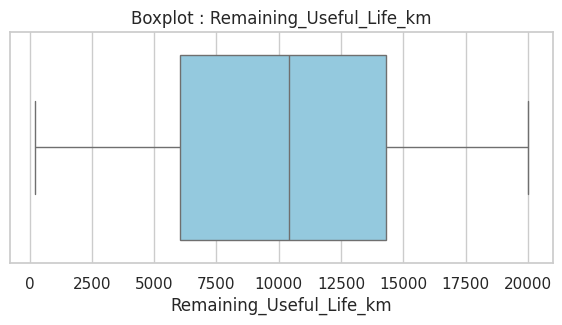


8. Important Categorical Features


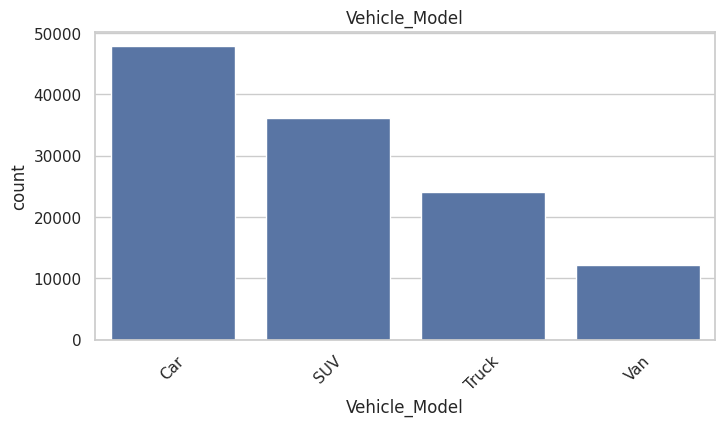

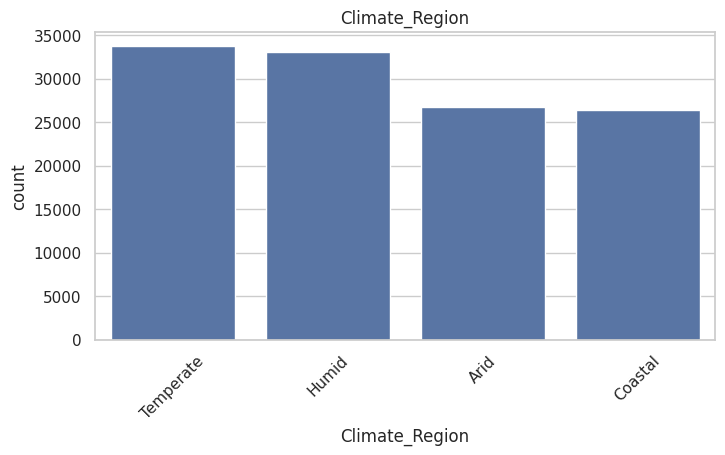

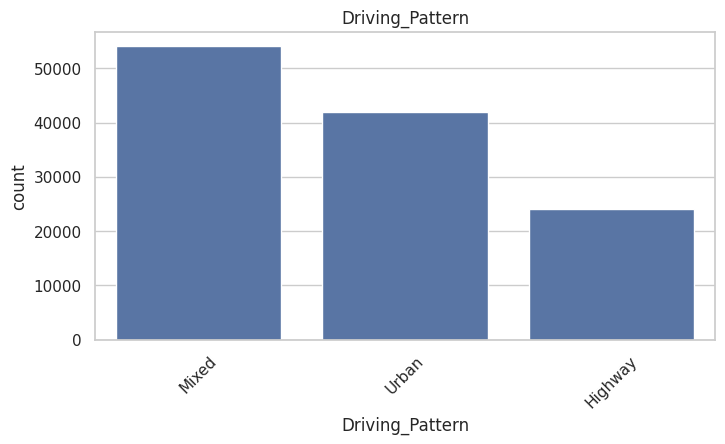

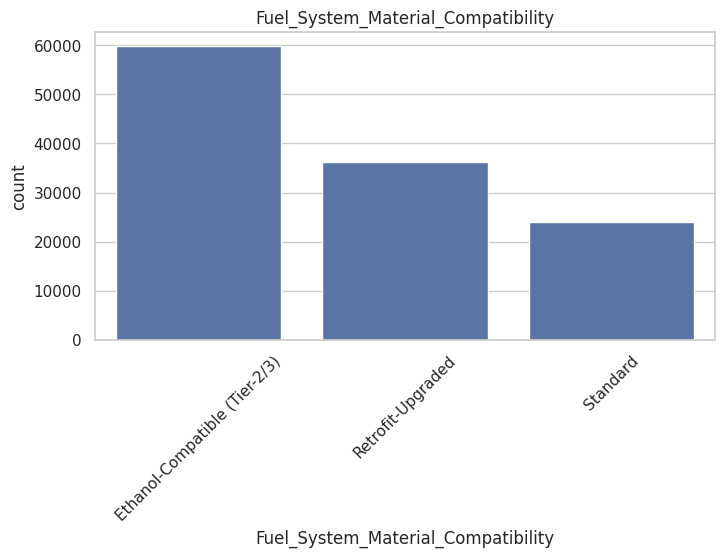


9. Important Features vs Need_Maintenance


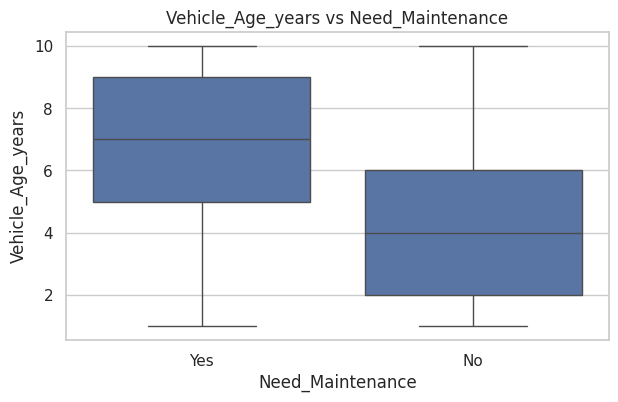

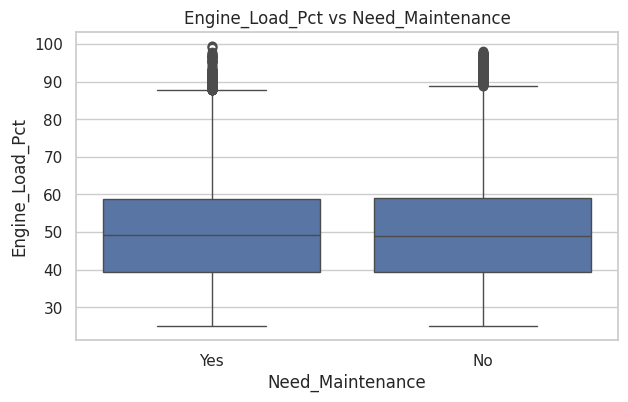

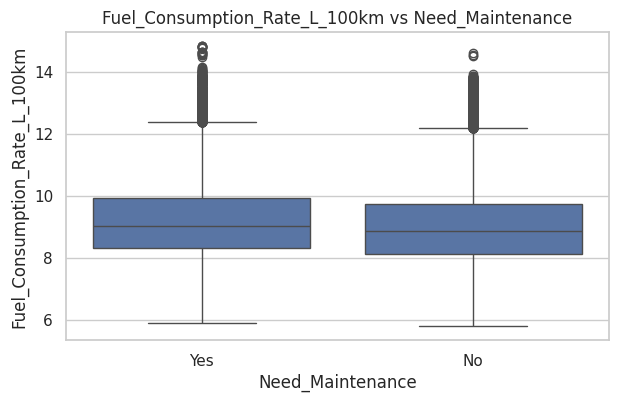

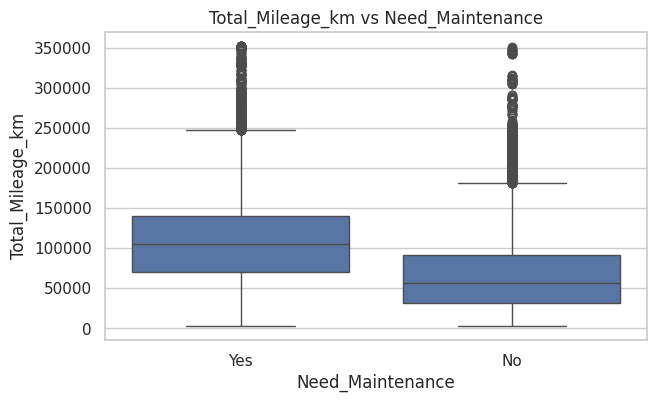

EDA OBSERVATIONS
• Target classes are nearly balanced.
• Multiple features contain missing values.
• No preprocessing has been performed.
• Correlation structure has been visualized.
• Outliers are present in several numerical features.
• Feature distributions have been explored.
• Dataset is ready for Stage 3 – Data Preprocessing.


In [16]:
# =============================================================================
# Stage 2 – Exploratory Data Analysis (EDA)
# Member 1
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Plot Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("="*80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 2 – Exploratory Data Analysis (EDA)")
print("="*80)

# =============================================================================
# 1. Target Variable Distribution
# =============================================================================

print("\n1. Need_Maintenance Distribution")

plt.figure(figsize=(6,4))
sns.countplot(data=vehicle_df, x="Need_Maintenance", palette="Set2")
plt.title("Need_Maintenance Distribution")
plt.xlabel("Need Maintenance")
plt.ylabel("Count")
plt.show()

print(vehicle_df["Need_Maintenance"].value_counts(normalize=True)*100)

# =============================================================================
# 2. Failure Type Distribution
# =============================================================================

print("\n2. Failure Type Distribution")

plt.figure(figsize=(10,5))
sns.countplot(
    data=vehicle_df,
    y="Failure_Type",
    order=vehicle_df["Failure_Type"].value_counts().index,
    palette="viridis"
)

plt.title("Failure Type Distribution")
plt.xlabel("Count")
plt.ylabel("Failure Type")
plt.show()

# =============================================================================
# 3. Remaining Useful Life Distribution
# =============================================================================

print("\n3. Remaining Useful Life Distribution")

plt.figure(figsize=(8,5))
sns.histplot(
    vehicle_df["Remaining_Useful_Life_km"],
    bins=40,
    kde=True
)

plt.title("Remaining Useful Life (km)")
plt.xlabel("Remaining Useful Life")
plt.show()

# =============================================================================
# 4. Missing Value Visualization
# =============================================================================

print("\n4. Missing Value Analysis")

missing = vehicle_df.isnull().mean()*100
missing = missing[missing>0].sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(
    x=missing.values,
    y=missing.index,
    palette="Reds_r"
)

plt.xlabel("Missing Percentage (%)")
plt.ylabel("Features")
plt.title("Missing Values")
plt.show()

# =============================================================================
# 5. Numerical Feature Distribution
# =============================================================================

print("\n5. Numerical Feature Distribution")

numeric_columns = vehicle_df.select_dtypes(
    include=["int64","float64"]
).columns

vehicle_df[numeric_columns].hist(
    figsize=(20,25),
    bins=30
)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. Correlation Heatmap
# =============================================================================

print("\n6. Correlation Heatmap")

plt.figure(figsize=(18,15))

corr = vehicle_df[numeric_columns].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

# =============================================================================
# 7. Outlier Analysis
# =============================================================================

print("\n7. Outlier Analysis")

important_features = [
    "Vehicle_Age_years",
    "Engine_Size_cc",
    "Fuel_Consumption_Rate_L_100km",
    "Engine_Load_Pct",
    "Total_Mileage_km",
    "Remaining_Useful_Life_km"
]

for feature in important_features:

    if feature in vehicle_df.columns:

        plt.figure(figsize=(7,3))

        sns.boxplot(
            x=vehicle_df[feature],
            color="skyblue"
        )

        plt.title(f"Boxplot : {feature}")
        plt.show()

# =============================================================================
# 8. Categorical Feature Distribution
# =============================================================================

print("\n8. Important Categorical Features")

categorical_features = [
    "Vehicle_Model",
    "Climate_Region",
    "Driving_Pattern",
    "Fuel_System_Material_Compatibility"
]

for feature in categorical_features:

    if feature in vehicle_df.columns:

        plt.figure(figsize=(8,4))

        sns.countplot(
            data=vehicle_df,
            x=feature,
            order=vehicle_df[feature].value_counts().index
        )

        plt.title(feature)
        plt.xticks(rotation=45)
        plt.show()

# =============================================================================
# 9. Relationship with Target
# =============================================================================

print("\n9. Important Features vs Need_Maintenance")

relationship_features = [
    "Vehicle_Age_years",
    "Engine_Load_Pct",
    "Fuel_Consumption_Rate_L_100km",
    "Total_Mileage_km"
]

for feature in relationship_features:

    if feature in vehicle_df.columns:

        plt.figure(figsize=(7,4))

        sns.boxplot(
            data=vehicle_df,
            x="Need_Maintenance",
            y=feature
        )

        plt.title(f"{feature} vs Need_Maintenance")
        plt.show()

# =============================================================================
# 10. EDA Summary
# =============================================================================

print("="*80)
print("EDA OBSERVATIONS")
print("="*80)

print("• Target classes are nearly balanced.")
print("• Multiple features contain missing values.")
print("• No preprocessing has been performed.")
print("• Correlation structure has been visualized.")
print("• Outliers are present in several numerical features.")
print("• Feature distributions have been explored.")
print("• Dataset is ready for Stage 3 – Data Preprocessing.")

Stage 3 Part 1

In [20]:
# =============================================================================
# Stage 3 – Data Preprocessing
# Part 1: Dataset copy, feature/target separation and common split
# =============================================================================

import os
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
PRIMARY_TARGET = "Need_Maintenance"

IDENTIFIER_COLUMNS = ["Vehicle_ID", "Timestamp"]

# Reuse the DataFrame created by Stage 1.
if "vehicle_df" not in globals():
    raise NameError(
        "vehicle_df is not available. Run the dataset loading cell and Stage 1 first."
    )

if not isinstance(vehicle_df, pd.DataFrame):
    raise TypeError("vehicle_df must be a pandas DataFrame.")

if vehicle_df.empty:
    raise ValueError("vehicle_df is empty.")

if PRIMARY_TARGET not in vehicle_df.columns:
    raise ValueError(f"Required target '{PRIMARY_TARGET}' was not found.")

# Never modify the original Stage 1 DataFrame.
df_stage3 = vehicle_df.copy(deep=True)

# Remove only columns that are actually present.
columns_to_remove = [c for c in IDENTIFIER_COLUMNS if c in df_stage3.columns]

if not columns_to_remove:
    print("Warning: no configured identifier columns were found.")

df_stage3 = df_stage3.drop(columns=columns_to_remove)

# Validate target before creating X/y.
if df_stage3[PRIMARY_TARGET].isna().any():
    raise ValueError(
        f"Target '{PRIMARY_TARGET}' contains missing values. "
        "Target rows must be resolved before supervised learning."
    )

if df_stage3[PRIMARY_TARGET].nunique(dropna=True) < 2:
    raise ValueError(
        f"Target '{PRIMARY_TARGET}' contains fewer than two classes."
    )

X = df_stage3.drop(columns=[PRIMARY_TARGET]).copy()
y_raw = df_stage3[PRIMARY_TARGET].copy()

if X.shape[1] == 0:
    raise ValueError("No predictor features remain after removing identifiers.")

# Encode the binary target once and reuse the same encoding for every model.
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)

target_classes = target_encoder.classes_.tolist()
target_mapping = {
    str(label): int(code)
    for label, code in zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))
}

print("=" * 80)
print("STAGE 3 – PART 1")
print("=" * 80)
print(f"Working dataset shape : {df_stage3.shape}")
print(f"Feature matrix shape  : {X.shape}")
print(f"Target classes        : {target_classes}")
print(f"Target mapping        : {target_mapping}")
print(f"Removed columns       : {columns_to_remove}")

# One split is used by RF, XGBoost and CatBoost for a fair comparison.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Reset indexes so the two preprocessing paths remain easy to compare.
X_train_raw = X_train_raw.reset_index(drop=True)
X_test_raw = X_test_raw.reset_index(drop=True)
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

print("\nTrain/Test split")
print(f"X_train_raw : {X_train_raw.shape}")
print(f"X_test_raw  : {X_test_raw.shape}")
print(f"y_train     : {y_train.shape}")
print(f"y_test      : {y_test.shape}")

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index().mul(100).round(2))

STAGE 3 – PART 1
Working dataset shape : (120000, 54)
Feature matrix shape  : (120000, 53)
Target classes        : ['No', 'Yes']
Target mapping        : {'No': 0, 'Yes': 1}
Removed columns       : ['Vehicle_ID', 'Timestamp']

Train/Test split
X_train_raw : (96000, 53)
X_test_raw  : (24000, 53)
y_train     : (96000,)
y_test      : (24000,)

Training class distribution:
0    50.69
1    49.31
Name: proportion, dtype: float64

Testing class distribution:
0    50.7
1    49.3
Name: proportion, dtype: float64


In [24]:
# =============================================================================
# Stage 3 – Part 2: Feature-type detection and reusable preprocessing definitions
# =============================================================================

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Validate that train/test schemas match exactly before preprocessing.
if list(X_train_raw.columns) != list(X_test_raw.columns):
    raise ValueError("Training and testing feature columns do not match.")

# Detect feature types from the training split only.
numeric_features = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_raw.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

unsupported_features = [
    c for c in X_train_raw.columns
    if c not in numeric_features and c not in categorical_features
]

if unsupported_features:
    raise TypeError(
        "Unsupported feature dtype(s) detected: "
        f"{unsupported_features}"
    )

if not numeric_features and not categorical_features:
    raise ValueError("No usable numeric or categorical features were detected.")

print("=" * 80)
print("STAGE 3 – PART 2")
print("=" * 80)
print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")

missing_train = X_train_raw.isna().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

print(f"\nTraining missing values before preprocessing: {int(X_train_raw.isna().sum().sum()):,}")

if not missing_train.empty:
    display(
        pd.DataFrame({
            "Missing Count": missing_train,
            "Missing Percentage": (
                missing_train / len(X_train_raw) * 100
            ).round(2)
        })
    )
else:
    print("No missing values in the training split.")

# Reusable imputers. They are fitted later through Pipeline/ColumnTransformer.
numeric_imputer = SimpleImputer(strategy="median")

categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

catboost_categorical_imputer = SimpleImputer(
    strategy="constant",
    fill_value="__MISSING__"
)

catboost_numeric_imputer = SimpleImputer(strategy="median")

print("\nReusable imputation definitions created successfully.")

STAGE 3 – PART 2
Numeric features     : 45
Categorical features : 8

Training missing values before preprocessing: 125,125


,Missing Count,Missing Percentage
Compression_Ratio_Change_Pct,9772,10.18
Fuel_Water_Contamination_ppm,8791,9.16
O2_Sensor_Response_ms,7691,8.01
Altitude_m,5720,5.96
Avg_Trip_Length_km,4899,5.10
Harsh_Event_Count_per_trip,4830,5.03
Fuel_Vapor_Pressure_Class,4697,4.89
Humidity_Pct,3835,3.99
Misfire_Count_per_1000rev,3010,3.14
Fuel_System_Corrosion_Score,2915,3.04



Reusable imputation definitions created successfully.


In [30]:
# =============================================================================
# Stage 3 – Part 3: Random Forest / XGBoost preprocessing
# =============================================================================

from sklearn.preprocessing import OneHotEncoder

# Use sparse output to reduce memory usage where supported.
try:
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )
except TypeError:
    # Compatibility fallback for older scikit-learn versions.
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

rf_xgb_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

# IMPORTANT: fit only on X_train_raw.
rf_xgb_preprocessor.fit(X_train_raw)

X_train_rf_xgb = rf_xgb_preprocessor.transform(X_train_raw)
X_test_rf_xgb = rf_xgb_preprocessor.transform(X_test_raw)

if X_train_rf_xgb.shape[0] != len(y_train):
    raise ValueError("RF/XGBoost training feature rows do not match y_train.")

if X_test_rf_xgb.shape[0] != len(y_test):
    raise ValueError("RF/XGBoost testing feature rows do not match y_test.")

if X_train_rf_xgb.shape[1] == 0:
    raise ValueError("RF/XGBoost preprocessing produced zero features.")

rf_xgb_feature_names = rf_xgb_preprocessor.get_feature_names_out().tolist()

if len(rf_xgb_feature_names) != X_train_rf_xgb.shape[1]:
    raise ValueError("Processed feature-name count does not match matrix width.")

print("=" * 80)
print("STAGE 3 – PART 3")
print("=" * 80)
print(f"RF/XGBoost train shape : {X_train_rf_xgb.shape}")
print(f"RF/XGBoost test shape  : {X_test_rf_xgb.shape}")
print(f"Processed feature count: {len(rf_xgb_feature_names)}")
print(f"Output type            : {type(X_train_rf_xgb).__name__}")

print("\nFirst 15 processed feature names:")
print(rf_xgb_feature_names[:15])

# Build a compact metadata object for later stages.
rf_xgb_metadata = {
    "pipeline_name": "RandomForest_XGBoost",
    "target": PRIMARY_TARGET,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "processed_feature_names": rf_xgb_feature_names,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE
}

print("\nRF/XGBoost preprocessing completed successfully.")


STAGE 3 – PART 3
RF/XGBoost train shape : (96000, 75)
RF/XGBoost test shape  : (24000, 75)
Processed feature count: 75
Output type            : csr_matrix

First 15 processed feature names:
['numeric__Vehicle_Age_years', 'numeric__Engine_Size_cc', 'numeric__Ambient_Temperature_C', 'numeric__Humidity_Pct', 'numeric__Altitude_m', 'numeric__Ethanol_Content_Pct', 'numeric__Fuel_Consumption_Rate_L_100km', 'numeric__Fuel_Rail_Pressure_kPa', 'numeric__Injector_Duty_Cycle_Pct', 'numeric__Fuel_Water_Contamination_ppm', 'numeric__LTFT_Pct', 'numeric__STFT_Pct', 'numeric__Oil_Pressure_psi', 'numeric__Oil_Temperature_C', 'numeric__Coolant_Temperature_C']

RF/XGBoost preprocessing completed successfully.


In [32]:
# =============================================================================
# Stage 3 – Part 4: CatBoost native categorical preprocessing
# =============================================================================

def prepare_catboost_data(
    X_train_input: pd.DataFrame,
    X_test_input: pd.DataFrame,
    numeric_cols: list,
    categorical_cols: list
):
    """Prepare CatBoost-compatible train/test DataFrames.

    Numeric missing values are fitted using training medians.
    Categorical missing values are replaced by a fixed string.
    Categorical columns are preserved as categorical features rather than OHE.
    """

    if list(X_train_input.columns) != list(X_test_input.columns):
        raise ValueError("CatBoost train/test columns do not match.")

    train = X_train_input.copy(deep=True)
    test = X_test_input.copy(deep=True)

    # Validate configured columns.
    all_expected = numeric_cols + categorical_cols
    missing_expected = [c for c in all_expected if c not in train.columns]

    if missing_expected:
        raise ValueError(
            f"Expected feature columns missing from CatBoost data: {missing_expected}"
        )

    # Numerical imputation: fit statistics on TRAINING data only.
    if numeric_cols:
        num_imputer = SimpleImputer(strategy="median")

        train_num = pd.DataFrame(
            num_imputer.fit_transform(train[numeric_cols]),
            columns=numeric_cols,
            index=train.index
        )

        test_num = pd.DataFrame(
            num_imputer.transform(test[numeric_cols]),
            columns=numeric_cols,
            index=test.index
        )

        train[numeric_cols] = train_num
        test[numeric_cols] = test_num
    else:
        num_imputer = None

    # Categorical imputation: replace missing values with a fixed category.
    if categorical_cols:
        cat_imputer = SimpleImputer(
            strategy="constant",
            fill_value="__MISSING__"
        )

        train_cat = pd.DataFrame(
            cat_imputer.fit_transform(train[categorical_cols]),
            columns=categorical_cols,
            index=train.index
        )

        test_cat = pd.DataFrame(
            cat_imputer.transform(test[categorical_cols]),
            columns=categorical_cols,
            index=test.index
        )

        # CatBoost requires categorical values to be strings.
        for col in categorical_cols:
            train_cat[col] = train_cat[col].astype(str)
            test_cat[col] = test_cat[col].astype(str)

        train[categorical_cols] = train_cat
        test[categorical_cols] = test_cat
    else:
        cat_imputer = None

    # Ensure no remaining missing values are passed to CatBoost.
    remaining_train_nan = int(train.isna().sum().sum())
    remaining_test_nan = int(test.isna().sum().sum())

    if remaining_train_nan or remaining_test_nan:
        raise ValueError(
            "CatBoost preprocessing left missing values: "
            f"train={remaining_train_nan}, test={remaining_test_nan}"
        )

    # Keep a deterministic column order.
    ordered_columns = numeric_cols + categorical_cols
    train = train[ordered_columns].copy()
    test = test[ordered_columns].copy()

    return train, test, num_imputer, cat_imputer


(
    X_train_catboost,
    X_test_catboost,
    catboost_numeric_imputer_fitted,
    catboost_categorical_imputer_fitted
) = prepare_catboost_data(
    X_train_raw,
    X_test_raw,
    numeric_features,
    categorical_features
)

# CatBoost accepts categorical feature names directly.
catboost_feature_names = categorical_features.copy()

# Also store indices for code that prefers indices.
catboost_feature_indices = [
    X_train_catboost.columns.get_loc(col)
    for col in catboost_feature_names
]

if X_train_catboost.shape[0] != len(y_train):
    raise ValueError("CatBoost training rows do not match y_train.")

if X_test_catboost.shape[0] != len(y_test):
    raise ValueError("CatBoost testing rows do not match y_test.")

if list(X_train_catboost.columns) != list(X_test_catboost.columns):
    raise ValueError("CatBoost train/test feature schemas differ.")

print("=" * 80)
print("STAGE 3 – PART 4")
print("=" * 80)
print(f"CatBoost train shape      : {X_train_catboost.shape}")
print(f"CatBoost test shape       : {X_test_catboost.shape}")
print(f"Categorical feature count : {len(catboost_feature_names)}")
print(f"Categorical feature names : {catboost_feature_names}")
print(f"Categorical feature index : {catboost_feature_indices}")

print("\nCatBoost data types:")
display(X_train_catboost.dtypes.to_frame("dtype"))

print("\nCatBoost preprocessing completed successfully.")


STAGE 3 – PART 4
CatBoost train shape      : (96000, 53)
CatBoost test shape       : (24000, 53)
Categorical feature count : 8
Categorical feature names : ['Vehicle_Model', 'Fuel_System_Material_Compatibility', 'Climate_Region', 'Fuel_Vapor_Pressure_Class', 'Towing_Flag', 'Driving_Pattern', 'Fuel_Line_Seal_Condition', 'Failure_Type']
Categorical feature index : [45, 46, 47, 48, 49, 50, 51, 52]

CatBoost data types:


,dtype
Vehicle_Age_years,float64
Engine_Size_cc,float64
Ambient_Temperature_C,float64
Humidity_Pct,float64
Altitude_m,float64
Ethanol_Content_Pct,float64
Fuel_Consumption_Rate_L_100km,float64
Fuel_Rail_Pressure_kPa,float64
Injector_Duty_Cycle_Pct,float64
Fuel_Water_Contamination_ppm,float64



CatBoost preprocessing completed successfully.


In [33]:
# =============================================================================
# Stage 3 – Part 5: Save reusable preprocessing artifacts
# =============================================================================

# Google Drive project directory.
PROJECT_DIR = Path("/content/drive/MyDrive/Btech Final Year Project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

# Create the artifact directory if Google Drive is mounted.
try:
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
except OSError as exc:
    raise OSError(
        f"Could not create artifact directory: {ARTIFACT_DIR}. "
        "Make sure Google Drive is mounted and writable."
    ) from exc

# Verify that the directory is writable.
if not os.access(ARTIFACT_DIR, os.W_OK):
    raise PermissionError(f"Artifact directory is not writable: {ARTIFACT_DIR}")

RF_XGB_PREPROCESSOR_PATH = ARTIFACT_DIR / "rf_xgb_preprocessor.joblib"
CATBOOST_PREPROCESSOR_PATH = ARTIFACT_DIR / "catboost_preprocessor.joblib"
PREPROCESSING_METADATA_PATH = ARTIFACT_DIR / "preprocessing_metadata.joblib"

# Save the fitted RF/XGBoost ColumnTransformer.
joblib.dump(
    rf_xgb_preprocessor,
    RF_XGB_PREPROCESSOR_PATH
)

# Save CatBoost imputers and categorical metadata.
catboost_artifacts = {
    "numeric_imputer": catboost_numeric_imputer_fitted,
    "categorical_imputer": catboost_categorical_imputer_fitted,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "categorical_feature_names": catboost_feature_names,
    "categorical_feature_indices": catboost_feature_indices,
    "feature_order": X_train_catboost.columns.tolist()
}

joblib.dump(
    catboost_artifacts,
    CATBOOST_PREPROCESSOR_PATH
)

# Save common project metadata.
preprocessing_metadata = {
    "project_stage": "Stage 3 – Data Preprocessing",
    "primary_target": PRIMARY_TARGET,
    "target_classes": target_classes,
    "target_mapping": target_mapping,
    "identifier_columns_removed": columns_to_remove,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "rf_xgb_feature_names": rf_xgb_feature_names,
    "catboost_feature_names": catboost_feature_names,
    "catboost_feature_indices": catboost_feature_indices,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "train_shape_raw": tuple(X_train_raw.shape),
    "test_shape_raw": tuple(X_test_raw.shape),
    "train_shape_rf_xgb": tuple(X_train_rf_xgb.shape),
    "test_shape_rf_xgb": tuple(X_test_rf_xgb.shape),
    "train_shape_catboost": tuple(X_train_catboost.shape),
    "test_shape_catboost": tuple(X_test_catboost.shape)
}

joblib.dump(
    preprocessing_metadata,
    PREPROCESSING_METADATA_PATH
)

# Save a small JSON metadata file for easy inspection outside Python.
metadata_json = {
    key: value
    for key, value in preprocessing_metadata.items()
    if isinstance(value, (str, int, float, bool, list, tuple))
}

with open(ARTIFACT_DIR / "preprocessing_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata_json, f, indent=2, default=list)

print("=" * 80)
print("PREPROCESSING ARTIFACTS SAVED")
print("=" * 80)

for path in [
    RF_XGB_PREPROCESSOR_PATH,
    CATBOOST_PREPROCESSOR_PATH,
    PREPROCESSING_METADATA_PATH,
    ARTIFACT_DIR / "preprocessing_metadata.json"
]:
    print(f"✓ {path}")


PREPROCESSING ARTIFACTS SAVED
✓ /content/drive/MyDrive/Btech Final Year Project/artifacts/rf_xgb_preprocessor.joblib
✓ /content/drive/MyDrive/Btech Final Year Project/artifacts/catboost_preprocessor.joblib
✓ /content/drive/MyDrive/Btech Final Year Project/artifacts/preprocessing_metadata.joblib
✓ /content/drive/MyDrive/Btech Final Year Project/artifacts/preprocessing_metadata.json


In [34]:
# =============================================================================
# Stage 3 – Part 6: Final verification
# =============================================================================

print("=" * 80)
print("STAGE 3 – FINAL VERIFICATION")
print("=" * 80)

# 1. Same sample counts across both pipelines.
assert X_train_rf_xgb.shape[0] == X_train_catboost.shape[0] == len(y_train)
assert X_test_rf_xgb.shape[0] == X_test_catboost.shape[0] == len(y_test)

# 2. Processed feature matrices are non-empty.
assert X_train_rf_xgb.shape[1] > 0
assert X_test_rf_xgb.shape[1] > 0
assert X_train_catboost.shape[1] > 0
assert X_test_catboost.shape[1] > 0

# 3. CatBoost data must contain no missing values.
assert int(X_train_catboost.isna().sum().sum()) == 0
assert int(X_test_catboost.isna().sum().sum()) == 0

# 4. Target vectors must contain at least two classes.
assert np.unique(y_train).size >= 2
assert np.unique(y_test).size >= 2

# 5. Saved artifacts must exist.
saved_paths = [
    RF_XGB_PREPROCESSOR_PATH,
    CATBOOST_PREPROCESSOR_PATH,
    PREPROCESSING_METADATA_PATH
]

for path in saved_paths:
    if not path.exists():
        raise FileNotFoundError(f"Expected artifact was not saved: {path}")

# 6. Reload the saved artifacts to verify serialization.
loaded_rf_xgb_preprocessor = joblib.load(RF_XGB_PREPROCESSOR_PATH)
loaded_catboost_artifacts = joblib.load(CATBOOST_PREPROCESSOR_PATH)
loaded_metadata = joblib.load(PREPROCESSING_METADATA_PATH)

assert hasattr(loaded_rf_xgb_preprocessor, "transform")
assert "categorical_feature_names" in loaded_catboost_artifacts
assert loaded_metadata["primary_target"] == PRIMARY_TARGET

print("✓ Same train-test split used for RF/XGBoost and CatBoost.")
print("✓ Target lengths match all processed training/testing datasets.")
print("✓ RF/XGBoost preprocessing produced non-empty features.")
print("✓ CatBoost data contains no unresolved missing values.")
print("✓ CatBoost categorical feature names and indices are available.")
print("✓ Preprocessing artifacts were saved and successfully reloaded.")
print("✓ No machine-learning model was trained in Stage 3.")

print("\n" + "=" * 80)
print("STAGE 3 CONCLUSION")
print("=" * 80)

print("Stage 3 completed successfully.")
print("The notebook is ready for Stage 4 – Machine Learning Models.")
print("Use:")
print("  • X_train_rf_xgb, X_test_rf_xgb for Random Forest and XGBoost")
print("  • X_train_catboost, X_test_catboost for CatBoost")
print("  • y_train and y_test as the common target arrays")
print("  • catboost_feature_names for CatBoost native categorical handling")


STAGE 3 – FINAL VERIFICATION
✓ Same train-test split used for RF/XGBoost and CatBoost.
✓ Target lengths match all processed training/testing datasets.
✓ RF/XGBoost preprocessing produced non-empty features.
✓ CatBoost data contains no unresolved missing values.
✓ CatBoost categorical feature names and indices are available.
✓ Preprocessing artifacts were saved and successfully reloaded.
✓ No machine-learning model was trained in Stage 3.

STAGE 3 CONCLUSION
Stage 3 completed successfully.
The notebook is ready for Stage 4 – Machine Learning Models.
Use:
  • X_train_rf_xgb, X_test_rf_xgb for Random Forest and XGBoost
  • X_train_catboost, X_test_catboost for CatBoost
  • y_train and y_test as the common target arrays
  • catboost_feature_names for CatBoost native categorical handling
